In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# FIND-S ALGORITHM
# DATASET: STUDENT SCHOLARSHIP ELIGIBILITY
# ---------------------------------------------------------

attributes = [
    'Attendance',
    'Marks',
    'Income',
    'Extracurricular'
]

data = [
    ['High',   'Excellent', 'Low',    'Yes', 'Yes'],
    ['High',   'Good',      'Low',    'Yes', 'Yes'],
    ['Medium', 'Good',      'Medium', 'No',  'No'],
    ['High',   'Excellent', 'Medium', 'Yes', 'Yes'],
    ['Low',    'Average',   'Low',    'No',  'No'],
    ['High',   'Good',      'Low',    'No',  'Yes']
]

df = pd.DataFrame(
    data,
    columns=attributes + ['Scholarship']
)

print("DATASET")
print(df)

X = df[attributes].values
y = df['Scholarship'].values

DATASET
  Attendance      Marks  Income Extracurricular Scholarship
0       High  Excellent     Low             Yes         Yes
1       High       Good     Low             Yes         Yes
2     Medium       Good  Medium              No          No
3       High  Excellent  Medium             Yes         Yes
4        Low    Average     Low              No          No
5       High       Good     Low              No         Yes


In [2]:
def find_s(X, y):

    hypothesis = ['0'] * len(X[0])

    history = []

    print("\nINITIAL HYPOTHESIS")
    print(hypothesis)

    for i, instance in enumerate(X):

        print("\n--------------------------------")
        print("Training Example:", i + 1)
        print("Instance:", instance)
        print("Output:", y[i])

        if y[i] == 'Yes':

            for j in range(len(hypothesis)):

                if hypothesis[j] == '0':
                    hypothesis[j] = instance[j]

                elif hypothesis[j] != instance[j]:
                    hypothesis[j] = '?'

            print("Positive Example")
            print("Updated Hypothesis:", hypothesis)

        else:

            print("Negative Example")
            print("Hypothesis remains:", hypothesis)

        history.append(hypothesis.copy())

    return hypothesis, history

In [3]:
final_hypothesis, history = find_s(X, y)


INITIAL HYPOTHESIS
['0', '0', '0', '0']

--------------------------------
Training Example: 1
Instance: ['High' 'Excellent' 'Low' 'Yes']
Output: Yes
Positive Example
Updated Hypothesis: ['High', 'Excellent', 'Low', 'Yes']

--------------------------------
Training Example: 2
Instance: ['High' 'Good' 'Low' 'Yes']
Output: Yes
Positive Example
Updated Hypothesis: ['High', '?', 'Low', 'Yes']

--------------------------------
Training Example: 3
Instance: ['Medium' 'Good' 'Medium' 'No']
Output: No
Negative Example
Hypothesis remains: ['High', '?', 'Low', 'Yes']

--------------------------------
Training Example: 4
Instance: ['High' 'Excellent' 'Medium' 'Yes']
Output: Yes
Positive Example
Updated Hypothesis: ['High', '?', '?', 'Yes']

--------------------------------
Training Example: 5
Instance: ['Low' 'Average' 'Low' 'No']
Output: No
Negative Example
Hypothesis remains: ['High', '?', '?', 'Yes']

--------------------------------
Training Example: 6
Instance: ['High' 'Good' 'Low' 'No']
Out

In [4]:
print("\n================================")
print("FINAL HYPOTHESIS")
print("================================")

for attribute, value in zip(
    attributes,
    final_hypothesis
):
    print(attribute, ":", value)


FINAL HYPOTHESIS
Attendance : High
Marks : ?
Income : ?
Extracurricular : ?


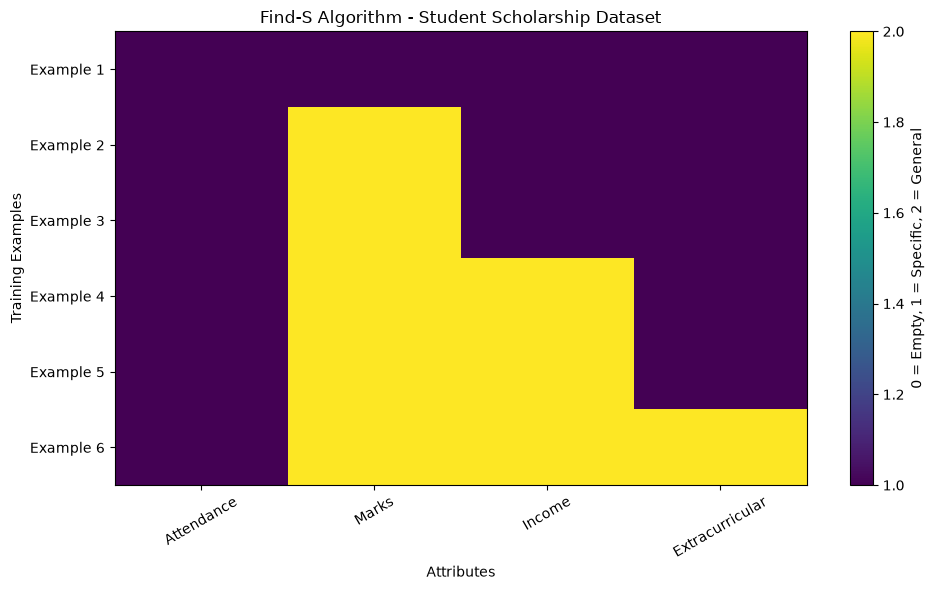

In [5]:
def encode_hypothesis(h):

    result = []

    for value in h:

        if value == '0':
            result.append(0)

        elif value == '?':
            result.append(2)

        else:
            result.append(1)

    return result


matrix = np.array(
    [
        encode_hypothesis(h)
        for h in history
    ]
)

plt.figure(figsize=(10, 6))

plt.imshow(
    matrix,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar(
    label='0 = Empty, 1 = Specific, 2 = General'
)

plt.xticks(
    range(len(attributes)),
    attributes,
    rotation=30
)

plt.yticks(
    range(len(history)),
    [
        f'Example {i + 1}'
        for i in range(len(history))
    ]
)

plt.title(
    'Find-S Algorithm - Student Scholarship Dataset'
)

plt.xlabel('Attributes')
plt.ylabel('Training Examples')

plt.tight_layout()

plt.show()